# Notebook 5 -- Modeling Dataset Construction and Leakage Control

**Goal:** build the final supervised-learning table and make the train/test split defensible.

This notebook is where the project becomes a serious ML project rather than just EDA. I explicitly defined:

- the prediction target,
- allowed predictors,
- leakage columns,
- train/test split strategy,
- preprocessing pipeline.

The main output is `data/processed/modeling_dataset.csv` plus optional train/test split CSVs for inspection.

In [1]:
# Core scientific stack
from pathlib import Path
import sys
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Resolve project root whether the notebook is run from /notebooks or from the repository root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"

for folder in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

# Notebook-aware figure saving -------------------------------------------------
# Every plot generated in this notebook is saved under reports/figures/.
# The counter prevents overwriting plots produced inside loops.
import re

NOTEBOOK_ID = "05_modeling_dataset_and_leakage_control"
_FIGURE_SAVE_COUNTER = 1


def _safe_filename(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_") or "figure"


def save_figure(fig, name: str = "figure", dpi: int = 180):
    """Save a matplotlib figure to reports/figures with a notebook-specific name."""
    global _FIGURE_SAVE_COUNTER
    filename = f"{NOTEBOOK_ID}_{_FIGURE_SAVE_COUNTER:02d}_{_safe_filename(name)}.png"
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path.relative_to(PROJECT_ROOT)}")
    _FIGURE_SAVE_COUNTER += 1
    return path


## 5.1 Loading configuration and base data

In [2]:
import yaml

from nigeria_crop_yield.features.build_features import build_modeling_dataset
from nigeria_crop_yield.models.train import make_preprocessor, split_data

CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

display(config)

NBS_CSV = PROCESSED_DIR / "nbs_crop_yield_state_zone_2022_2023.csv"
STATE_META_CSV = PROCESSED_DIR / "state_metadata.csv"
CLIMATE_FEATURES_CSV = RAW_DIR / "climate" / "nasa_power_daily_state_centroids_2022_2023.csv"
SENTINEL_FEATURES_CSV = INTERIM_DIR / "sentinel2_state_crop_season_features.csv"
MODELING_CSV = PROCESSED_DIR / "modeling_dataset.csv"

{'project': {'name': 'crop-yield-nigeria-geoai', 'random_state': 42},
 'paths': {'nbs_xlsx': 'data/raw/nbs/nass_report_tables_2022_2023.xlsx',
  'nbs_processed': 'data/processed/nbs_crop_yield_state_zone_2022_2023.csv',
  'state_metadata': 'data/processed/state_metadata.csv',
  'climate_daily': 'data/raw/climate/nasa_power_daily_state_centroids_2022_2023.csv',
  'sentinel_features': 'data/interim/sentinel2_monthly_indices_state_crop_2022_2023.csv',
  'modeling_dataset': 'data/processed/modeling_dataset.csv',
  'model_dir': 'models',
  'report_dir': 'reports'},
 'nbs': {'download_url': 'https://microdata.nigerianstat.gov.ng/index.php/catalog/173/download/1303',
  'source_name': 'National Agricultural Sample Survey 2022/2023 report tables',
  'exclude_aggregate_rows': True,
  'target': 'yield_kg_ha'},
 'climate': {'provider': 'nasa_power',
  'start_date': '2022-01-01',
  'end_date': '2023-12-31',
  'parameters': ['PRECTOTCORR', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'WS2M']},
 'sentinel2':

## 5.2 Building the modeling dataset

This function excludes aggregate rows and joins metadata. Climate and Sentinel-2 paths are optional. If those files do not exist, the dataset still builds from NBS + state metadata.

In [3]:
climate_path = CLIMATE_FEATURES_CSV if CLIMATE_FEATURES_CSV.exists() else None
sentinel_path = SENTINEL_FEATURES_CSV if SENTINEL_FEATURES_CSV.exists() else None

modeling_df = build_modeling_dataset(
    nbs_path=NBS_CSV,
    state_metadata_path=STATE_META_CSV,
    output_path=MODELING_CSV,
    climate_path=climate_path,
    sentinel_path=sentinel_path,
    climate_source="nasa_power",
    exclude_aggregates=True,
)

print("Saved:", MODELING_CSV)
print(modeling_df.shape)
display(modeling_df.head())

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\data\processed\modeling_dataset.csv
(490, 27)


,season,zone,state,crop,households_reporting_000,planted_area_ha,harvested_area_ha,harvested_quantity_kg,yield_kg_ha,is_aggregate,source_sheet,source_table,geopolitical_zone,agroecological_zone,latitude,longitude,log_planted_area_ha,total_rainfall_mm,mean_tmean_c,mean_tmax_c,mean_tmin_c,mean_rh_percent,mean_wind_speed_m_s,growing_degree_days,heat_stress_days,mean_solar_radiation_kwh_m2_day,total_solar_radiation_kwh_m2
0,major,North Central,Benue,MAIZE,850.39,367795.171270,350398.700331,3.939929e+08,1124.413179,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.34,8.74,12.815284,2791.10,25.855397,30.575918,21.825959,75.860397,1.950466,11574.44,2.0,18.280082,13344.46
1,major,North Central,FCT,MAIZE,266.34,153246.079216,123737.798835,1.606178e+08,1298.049753,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,9.08,7.40,11.939807,2791.66,25.271973,31.020178,20.592260,71.285904,1.552260,11148.54,94.0,19.003315,13872.42
2,major,North Central,Kogi,MAIZE,640.86,327793.065371,309235.626289,4.257146e+08,1376.667527,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,7.80,6.74,12.700141,2922.19,25.946644,30.472301,21.926014,77.683192,1.599945,11641.05,2.0,17.665493,12895.81
3,major,North Central,Kwara,MAIZE,398.11,307483.872742,301489.864767,5.002011e+08,1659.097522,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.50,4.55,12.636181,3120.12,25.177890,30.194986,21.067233,78.085986,1.852548,11079.86,11.0,18.085219,13202.21
4,major,North Central,Nasarawa,MAIZE,520.48,416547.122485,360177.787028,4.213675e+08,1169.887511,False,Crop Production2_major season,Table 1.1: Main 9 crops highly cultivated in a...,North Central,Southern Guinea Savannah,8.54,8.32,12.939757,2904.55,26.104479,31.606562,21.643397,71.356986,1.675493,11756.27,113.0,18.834699,13749.33


## 5.3 Defining target and leakage columns

The target is `yield_kg_ha`. Because yield is computed from harvested quantity and harvested area, those variables should not be used as predictive features in the main benchmark. They are useful for auditing, not for honest prediction.

In [4]:
TARGET = config["nbs"].get("target", "yield_kg_ha")
LEAKAGE_COLUMNS = set(config["modeling"].get("leakage_columns", []))

print("Target:", TARGET)
print("Leakage-sensitive columns:")
for c in sorted(LEAKAGE_COLUMNS):
    print(" -", c, "| present:", c in modeling_df.columns)

candidate_numeric = config["modeling"].get("numeric_features", [])
candidate_categorical = config["modeling"].get("categorical_features", [])

numeric_features = [c for c in candidate_numeric if c in modeling_df.columns and c not in LEAKAGE_COLUMNS]
categorical_features = [c for c in candidate_categorical if c in modeling_df.columns and c not in LEAKAGE_COLUMNS]
feature_cols = numeric_features + categorical_features

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total features before encoding:", len(feature_cols))

Target: yield_kg_ha
Leakage-sensitive columns:
 - harvested_area_ha | present: True
 - harvested_quantity_kg | present: True
 - yield_kg_ha | present: True
Numeric features: ['households_reporting_000', 'planted_area_ha', 'latitude', 'longitude', 'total_rainfall_mm', 'mean_tmean_c', 'mean_tmax_c', 'mean_tmin_c', 'mean_rh_percent', 'growing_degree_days', 'heat_stress_days']
Categorical features: ['crop', 'season', 'zone', 'agroecological_zone']
Total features before encoding: 15


## 5.4 Checking for missingness in the modeling features

Missingness determines whether imputation is needed. I used median imputation for numeric variables and most-frequent imputation for categorical variables.

,column,missing_percent
0,households_reporting_000,0.0
1,planted_area_ha,0.0
2,latitude,0.0
3,longitude,0.0
4,total_rainfall_mm,0.0
5,mean_tmean_c,0.0
6,mean_tmax_c,0.0
7,mean_tmin_c,0.0
8,mean_rh_percent,0.0
9,growing_degree_days,0.0


Saved figure: reports\figures\05_modeling_dataset_and_leakage_control_01_figure_01.png


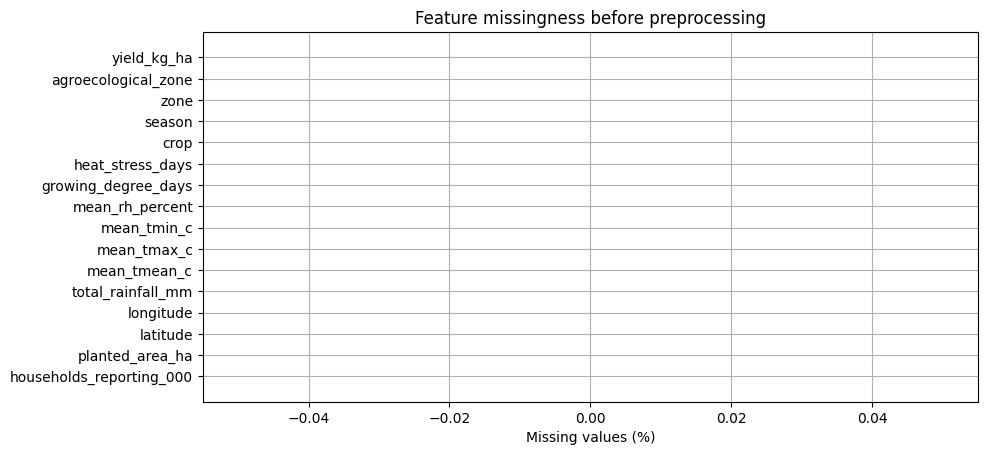

In [5]:
feature_missing = (
    modeling_df[feature_cols + [TARGET]]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_percent", ascending=False)
)
display(feature_missing)

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(feature_missing))))
plot_df = feature_missing.sort_values("missing_percent")
ax.barh(plot_df["column"], plot_df["missing_percent"])
ax.set_xlabel("Missing values (%)")
ax.set_title("Feature missingness before preprocessing")
save_figure(fig, "figure_01")
plt.show()

## 5.5 Train/test split with state grouping

A random row split can leak state-specific information because the same state may appear in both train and test for different crops. A grouped split by state is a stricter and more realistic validation setup.

In [6]:
train_df, test_df = split_data(
    modeling_df,
    target=TARGET,
    test_size=config["modeling"].get("test_size", 0.25),
    random_state=RANDOM_STATE,
    group_col="state",
)

print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train states:", train_df["state"].nunique(), "| Test states:", test_df["state"].nunique())
print("State overlap:", sorted(set(train_df["state"]).intersection(set(test_df["state"]))))

display(train_df[["state", "crop", "season", TARGET]].head())
display(test_df[["state", "crop", "season", TARGET]].head())

Train rows: 368 | Test rows: 122
Train states: 27 | Test states: 10
State overlap: []


,state,crop,season,yield_kg_ha
1,FCT,MAIZE,major,1298.049753
2,Kogi,MAIZE,major,1376.667527
3,Kwara,MAIZE,major,1659.097522
6,Plateau,MAIZE,major,1302.532050
7,Adamawa,MAIZE,major,1304.120312


,state,crop,season,yield_kg_ha
0,Benue,MAIZE,major,1124.413179
4,Nasarawa,MAIZE,major,1169.887511
5,Niger,MAIZE,major,1180.496021
8,Bauchi,MAIZE,major,1348.535400
12,Yobe,MAIZE,major,1149.806247


## 5.6 Split-balance diagnostics

The test set should contain enough crops, zones, and seasons to make evaluation meaningful.

In [7]:
def split_summary(df, name):
    return {
        "split": name,
        "rows": len(df),
        "states": df["state"].nunique(),
        "crops": df["crop"].nunique(),
        "zones": df["zone"].nunique(),
        "mean_yield": df[TARGET].mean(),
        "median_yield": df[TARGET].median(),
    }

summary = pd.DataFrame([split_summary(train_df, "train"), split_summary(test_df, "test")])
display(summary)

for col in ["season", "zone", "agroecological_zone"]:
    if col in modeling_df.columns:
        tab = pd.crosstab(modeling_df[col], modeling_df.index.isin(test_df.index), normalize="columns").rename(columns={False: "train", True: "test"})
        print_section(f"Split distribution: {col}")
        display(tab)

,split,rows,states,crops,zones,mean_yield,median_yield
0,train,368,27,22,6,2522.023618,1591.447900
1,test,122,10,22,5,2166.085724,1410.107696



Split distribution: season


col_0,train,test
season,,
major,0.861413,0.893443
minor,0.138587,0.106557



Split distribution: zone


col_0,train,test
zone,,
North Central,0.171196,0.385246
North East,0.149457,0.204918
North West,0.263587,0.090164
South East,0.078804,0.155738
South South,0.187500,0.000000
South West,0.149457,0.163934



Split distribution: agroecological_zone


col_0,train,test
agroecological_zone,,
Derived Savannah / Humid Forest Transition,0.228261,0.213115
Humid Forest,0.059783,0.065574
Humid Forest / Mangrove,0.065217,0.000000
Mangrove / Coastal Rainforest,0.062500,0.040984
Montane / Northern Guinea Savannah,0.038043,0.000000
Northern Guinea Savannah,0.130435,0.000000
Sahel / Sudan Savannah,0.070652,0.065574
Sahel Savannah,0.048913,0.000000
Southern Guinea Savannah,0.133152,0.385246


## 5.7 Building and inspecting the preprocessing pipeline

The estimator will receive a numeric matrix after imputation, scaling, and one-hot encoding.

In [8]:
preprocessor = make_preprocessor(numeric_features, categorical_features)
X_train = train_df[feature_cols]
y_train = train_df[TARGET]

Xt = preprocessor.fit_transform(X_train, y_train)
print("Raw feature columns:", len(feature_cols))
print("Encoded feature matrix shape:", Xt.shape)

try:
    encoded_names = preprocessor.get_feature_names_out()
    display(pd.DataFrame({"encoded_feature": encoded_names}).head(50))
except Exception as exc:
    print("Could not extract encoded names:", repr(exc))

Raw feature columns: 15
Encoded feature matrix shape: (368, 51)


,encoded_feature
0,households_reporting_000
1,planted_area_ha
2,latitude
3,longitude
4,total_rainfall_mm
5,mean_tmean_c
6,mean_tmax_c
7,mean_tmin_c
8,mean_rh_percent
9,growing_degree_days


## 5.8 Saving the train/test split snapshots

In [9]:
TRAIN_CSV = INTERIM_DIR / "train_split_state_grouped.csv"
TEST_CSV = INTERIM_DIR / "test_split_state_grouped.csv"

train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("Saved:", TRAIN_CSV)
print("Saved:", TEST_CSV)

Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\data\interim\train_split_state_grouped.csv
Saved: c:\Users\Peter\Documents\projects\SHORT PROJECTS\ml-projects\crop-yield-nigeria-geoai\data\interim\test_split_state_grouped.csv
